# Imports

In [1]:
# Linear algebra
import numpy as np

# Dataframes
import pandas as pd

# Path
import os
data_path = os.path.join('..', 'data')
virus_data_path = os.path.join('..', 'data', 'human_viruses')

# Json
import json

# Plotting
# import seaborn as sns
import matplotlib.pyplot as plt

# Load and Merge Virus Data

## Load and Merge CSV Files

In [166]:
# load virus csvs
viral_proteins_df = pd.read_csv(os.path.join(virus_data_path, '_viral_proteins.csv'))
viruses_df = pd.read_csv(os.path.join(virus_data_path, '_viruses.csv'))
viralzone_viruses_df = pd.read_csv(os.path.join(virus_data_path, '_viralzone_viruses.csv')).dropna(subset=['Species'])

In [167]:
# merge viruses_df into viral_proteins_df on "Species" column
merged_df = viral_proteins_df.merge(viruses_df, on='Species')

In [168]:
merged_df.loc[merged_df['Protein.ID'] == 'NP_050222']

,Protein.ID,Accession,VOG,annotation,Division,Taxid,Species,Organelle,X..Codons,GC.,...,GGT,GGC,GGA,GGG,tropism,type,family,genus,Baltimore,Aiewsakun2018
2066,NP_050222,NC_000898,VOG05390,XrXs,refseq,32604,Human betaherpesvirus 6B,genomic,1133,38.28,...,23,11,10,3,Immune cells,dsDNA,Herpesviridae,Roseolovirus,I,Herpesviridae


## Add Codon Sequences from FASTA

In [169]:
# load fasta file with protein sequences, and parse it
# each row identifier has the pattern ">lcl|Accession... [gene=genename] [locus_tag=locus] [db_xref=GeneID:#######] [protein=protein description] [protein_id='Protein.ID'.version] [location=complement(pos1..pos2)] [gbkey=CDS]"
# the dna sequence follows the row identifier

# read fasta file
fasta_file = os.path.join(virus_data_path, 'refseq_humanvirus.fasta')
with open(fasta_file, 'r') as f:
    lines = f.readlines()

# parse fasta file
fasta_dict = {}
current_protein_id = None
current_sequence = []

for line in lines:
    if line.startswith('>'):
        if current_protein_id:
            fasta_dict[current_protein_id] = ''.join(current_sequence)
        # get protein id
        current_protein_id = line.split(' ')[-3].split('=')[-1].split('.')[0]
        current_sequence = []
    else:
        current_sequence.append(line.strip())

# add the last protein sequence to the dictionary
if current_protein_id:
    fasta_dict[current_protein_id] = ''.join(current_sequence)

# add protein sequences to merged_df
merged_df['codon_seq'] = merged_df['Protein.ID'].apply(lambda x: fasta_dict[x] if x in fasta_dict else None)

In [170]:
merged_df

,Protein.ID,Accession,VOG,annotation,Division,Taxid,Species,Organelle,X..Codons,GC.,...,GGC,GGA,GGG,tropism,type,family,genus,Baltimore,Aiewsakun2018,codon_seq
0,YP_009552823,NC_040671,VOG00934,XhXr,refseq,272636,Adeno-associated virus,genomic,649,50.49,...,10,13,9,NaN,ssDNA,Parvoviridae,Dependoparvovirus,II,Parvoviridae,ATGACGACACCTACGTACTACGAGCTGATTGTGGAGCTGCCGAGCG...
1,YP_009552824,NC_040671,VOG01499,XhXpXs,refseq,272636,Adeno-associated virus,genomic,739,51.51,...,11,36,5,NaN,ssDNA,Parvoviridae,Dependoparvovirus,II,Parvoviridae,ATGTCTGCTGCTGATTCTGTTCCAGATTGGTTGGAGAATTTTGTGC...
2,NP_049541,NC_002077,NaN,NaN,refseq,85106,Adeno-associated virus - 1,genomic,624,59.40,...,19,3,10,NaN,ssDNA,Parvoviridae,Dependoparvovirus,II,Parvoviridae,ATGCCGGGCTTCTACGAGATCGTGATCAAGGTGCCGAGCGACCTGG...
3,NP_049542,NC_002077,NaN,NaN,refseq,85106,Adeno-associated virus - 1,genomic,737,53.82,...,26,20,8,NaN,ssDNA,Parvoviridae,Dependoparvovirus,II,Parvoviridae,ATGGCTGCCGATGGTTATCTTCCAGATTGGCTCGAGGACAACCTCT...
4,YP_680422,NC_001401,NaN,NaN,refseq,10804,Adeno-associated virus - 2,genomic,537,54.56,...,5,9,13,NaN,ssDNA,Parvoviridae,Dependoparvovirus,II,Parvoviridae,ATGCCGGGGTTTTACGAGATTGTGATTAAGGTCCCCAGCGACCTTG...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6082,NP_066249,NC_002549,VOG06182,Xs,refseq,186538,Zaire ebolavirus,genomic,289,44.75,...,1,5,4,NaN,ssRNA(-),Filoviridae,Ebolavirus,V,Filoviridae,ATGGAAGCTTCATATGAGAGAGGACGCCCACGAGCTGCCAGACAGC...
6083,NP_066250,NC_002549,VOG06187,XhXs,refseq,186538,Zaire ebolavirus,genomic,252,42.72,...,0,6,4,NaN,ssRNA(-),Filoviridae,Ebolavirus,V,Filoviridae,ATGGCTAAAGCTACGGGACGATACAATCTAATATCGCCCAAAAAGG...
6084,NP_066251,NC_002549,VOG00372,XhXrXs,refseq,186538,Zaire ebolavirus,genomic,2213,39.60,...,12,36,22,NaN,ssRNA(-),Filoviridae,Ebolavirus,V,Filoviridae,ATGGCTACACAACATACCCAATACCCAGACGCTAGGTTATCATCAC...
6085,YP_002790881,NC_012532,NaN,NaN,refseq,64320,Zika virus,genomic,3420,50.77,...,51,150,67,NaN,ssRNA(+),Flaviviridae,Flavivirus,IV,Flaviviridae,ATGAAAAACCCCAAAGAAGAAATCCGGAGGATCCGGATTGTCAATA...


## Add Hosts

In [171]:
viralzone_viruses_df['Genome'] = viralzone_viruses_df['Genome'].apply(lambda x: x.split(', '))
viralzone_viruses_df['Host'] = viralzone_viruses_df['Host'].apply(lambda x: x.split(', '))

In [172]:
new_columns = viralzone_viruses_df.explode('Genome')[['Genome', 'Host']]

merged_df = merged_df.merge(new_columns, left_on='Accession', right_on='Genome', how='left').drop(columns=['Genome'])

<Axes: xlabel='tropism'>

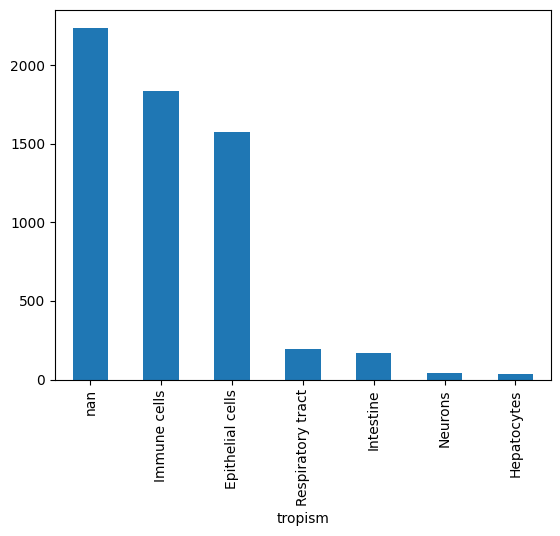

In [173]:
# value counts of protein tropism including NaN values
merged_df['tropism'].value_counts(dropna=False).plot(kind='bar')

<Axes: >

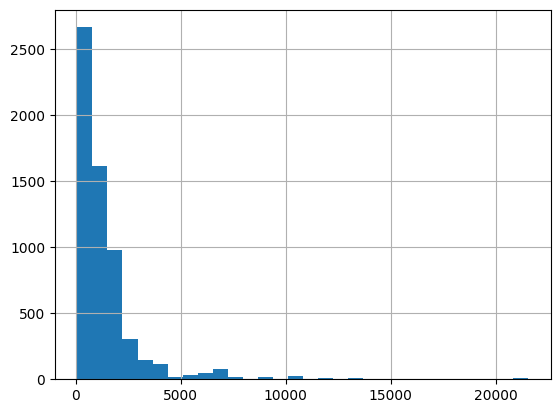

In [175]:
# codon_seq length histogram
merged_df['codon_seq'].apply(lambda x: len(x) if x else 0).hist(bins=30)

# Clean Virus Dataset

**Drop codon sequences that are not a multiple of 3.**

In [176]:
seq_not_multiple_of_3_indices = \
    merged_df.loc[(merged_df['codon_seq'].apply(lambda x: len(x)) % 3) != 0].index

# remove sequences that are not multiple of 3
merged_df.drop(seq_not_multiple_of_3_indices, inplace=True)

print(f'{len(seq_not_multiple_of_3_indices)} sequences removed.')

16 sequences removed.


**Drop ambiguous codon sequences.**

In [177]:
nts = set(['A', 'T', 'C', 'G'])
ambiguous_seq_indices = \
    merged_df[merged_df['codon_seq'].apply(lambda x: (set(x) - nts) != set())].index

# remove sequences with IUPAC ambiguous nucleotides
merged_df.drop(ambiguous_seq_indices, inplace=True)

print(f'{len(ambiguous_seq_indices)} sequences removed.')

52 sequences removed.


In [178]:
len(merged_df.loc[merged_df['codon_seq'].apply(lambda x: x[:3] != 'ATG')].index)

42

In [179]:
len(merged_df)

6019

In [180]:
len(merged_df.loc[112, 'codon_seq']) / 3

KeyError: 112

# Save Merged Virus Dataset

In [181]:
merged_df.reset_index(drop=True, inplace=True)
pd.to_pickle(merged_df, os.path.join(virus_data_path, 'human_viruses.pkl'))

# Add Expression Vectors

## Load Data

In [2]:
human_viruses = pd.read_pickle(os.path.join(virus_data_path, 'human_viruses.pkl'))
test_with_results = pd.read_pickle(os.path.join(data_path, '2_test_with_bart30.pkl'))
human_genes = pd.read_pickle(os.path.join(data_path, 'genes_human_discrete_expression.pkl'))

In [3]:
len(human_viruses)

6019

## Sample Expression Vectors Randomly

In [184]:
# Ensure 'median' column in test_with_results is numeric
median_vectors = test_with_results['median']

# Sample from median vectors
len_human_viruses = len(human_viruses)
sample = median_vectors.sample(n=len_human_viruses, random_state=42)

# Add sample to human_viruses
human_viruses['expression_random'] = sample.values

In [185]:
human_viruses['expression_random']

0                                                     NaN
1       (expr_pre75_90, expr_pre75_90, expr_pre75_90, ...
2       (expr_pre75_90, expr_top10, expr_pre75_90, exp...
3       (expr_low25, expr_low25, expr_low25, expr_low2...
4       (expr_low25, expr_low25, expr_low25, expr_low2...
                              ...                        
6014    (expr_pre50_75, expr_pre50_75, expr_pre75_90, ...
6015    (expr_pre75_90, expr_pre75_90, expr_pre50_75, ...
6016                                                  NaN
6017    (expr_pre25_50, expr_pre25_50, expr_pre50_75, ...
6018    (expr_low25, expr_low25, expr_low25, expr_low2...
Name: expression_random, Length: 6019, dtype: object

## Sample Expression Vectors From Different Transcripts Expression Levels

In [186]:
# Convert 'median' to categorical integers
expression_categories = ['expr_low25', 'expr_pre25_50', 'expr_pre50_75', 'expr_pre75_90', 'expr_top10']
median_vectors = test_with_results['median']
median_vectors_ints = median_vectors.apply(lambda x: tuple(expression_categories.index(cat) for cat in x) if not isinstance(x, float) else x)

# Mean for each vector
median_vector_means = median_vectors_ints.apply(lambda x: np.mean(x) if not isinstance(x, float) else x)

# High Expression medians
high_expression_vectors = median_vectors[median_vector_means > 3]
# Medium-High Expression medians
medium_high_expression_vectors = median_vectors[(median_vector_means > 2) & (median_vector_means <= 3)]
# Medium-Low Expression medians
medium_low_expression_vectors = median_vectors[(median_vector_means > 1) & (median_vector_means <= 2)]
# Low Expression medians
low_expression_vectors = median_vectors[median_vector_means <= 1]

# Sample from high expression vectors
len_high_expression_vectors = len(high_expression_vectors)
sample_high = high_expression_vectors.sample(n=len_human_viruses, replace=True, random_state=42)
# Sample from medium-high expression vectors
len_medium_high_expression_vectors = len(medium_high_expression_vectors)
sample_medium_high = medium_high_expression_vectors.sample(n=len_human_viruses, replace=True, random_state=42)
# Sample from medium-low expression vectors
len_medium_low_expression_vectors = len(medium_low_expression_vectors)
sample_medium_low = medium_low_expression_vectors.sample(n=len_human_viruses, replace=True, random_state=42)
# Sample from low expression vectors
len_low_expression_vectors = len(low_expression_vectors)
sample_low = low_expression_vectors.sample(n=len_human_viruses, replace=True, random_state=42)

# Add sample to human_viruses
human_viruses['expression_high'] = sample_high.values
human_viruses['expression_medium_high'] = sample_medium_high.values
human_viruses['expression_medium_low'] = sample_medium_low.values
human_viruses['expression_low'] = sample_low.values

## Naive Aligned Expression Vectors

In [188]:
tropisms = list(set(human_viruses['tropism'].dropna()))

tissues = human_genes.loc[0, 'tissueSiteDetailId']

tropism_to_tissue = {
    'Epithelial cells': [
        'Bladder', 'Breast_Mammary_Tissue', 'Cervix_Ectocervix', 'Cervix_Endocervix',
        'Esophagus_Mucosa', 'Esophagus_Muscularis', 'Fallopian_Tube', 'Ovary', 
        'Pancreas', 'Prostate', 'Skin_Not_Sun_Exposed_Suprapubic', 'Skin_Sun_Exposed_Lower_leg', 
        'Testis', 'Thyroid', 'Uterus', 'Vagina', 'Minor_Salivary_Gland'
    ],
    'Hepatocytes': ['Liver'],
    'Immune cells': ['Spleen', 'Whole_Blood', 'Cells_EBV-transformed_lymphocytes'],
    'Intestine': ['Small_Intestine_Terminal_Ileum', 'Colon_Sigmoid', 'Colon_Transverse', 'Stomach'],
    'Neurons': [
        'Brain_Amygdala', 'Brain_Anterior_cingulate_cortex_BA24', 'Brain_Caudate_basal_ganglia', 
        'Brain_Cerebellar_Hemisphere', 'Brain_Cerebellum', 'Brain_Cortex', 'Brain_Frontal_Cortex_BA9', 
        'Brain_Hippocampus', 'Brain_Hypothalamus', 'Brain_Nucleus_accumbens_basal_ganglia', 
        'Brain_Putamen_basal_ganglia', 'Brain_Spinal_cord_cervical_c-1', 'Brain_Substantia_nigra', 
        'Nerve_Tibial'
    ],
    'Respiratory tract': ['Lung', 'Esophagus_Gastroesophageal_Junction']
}


low_exp_token = 'expr_low25'
high_exp_token = 'expr_top10'

# copy low_exp_token to an array with length len(tissues)
low_exp_arr = np.array([low_exp_token] * len(tissues))
def tropism_exp_vector(x):
    result = low_exp_arr.copy()
    result[[tissues.index(tissue) for tissue in tropism_to_tissue[x]]] = high_exp_token
    return tuple(result.tolist())

tropism_to_expression_vectors = {tropism:tropism_exp_vector(tropism) for tropism in tropisms}

human_viruses['expression_naive_aligned'] = human_viruses['tropism'].map(tropism_to_expression_vectors)

In [211]:
medium_high_exp_token = 'expr_pre50_75'

def tropism_exp_vector_1(x):
    result = np.empty(len(tissues), dtype=object)
    result[[tissues.index(tissue) for tissue in tropism_to_tissue[x]]] = medium_high_exp_token
    return tuple(result.tolist())

tropism_to_expression_vectors_1 = {tropism:tropism_exp_vector_1(tropism) for tropism in tropisms}

human_viruses['expression_naive_aligned_1'] = human_viruses['tropism'].map(tropism_to_expression_vectors_1)

## Naive Aligned Shuffled (Misaligned)

In [7]:
human_viruses['expression_naive_shuffled'] = human_viruses['expression_naive_aligned'].sample(frac=1, random_state=42).reset_index(drop=True)
human_viruses['expression_naive_shuffled_1'] = human_viruses['expression_naive_aligned_1'].sample(frac=1, random_state=42).reset_index(drop=True)

# Save Virus Dataset

In [11]:
# Save human_viruses to pickle
human_viruses.to_pickle(os.path.join(virus_data_path, 'human_viruses.pkl'))

# save human_viruses to csv with json strings
human_viruses_copy = human_viruses.copy()

def convert_to_json_string(value):
    if pd.isna(value):
        return value
    return json.dumps(value)

for col in ['expression_random', 'expression_high', 'expression_medium_high', 'expression_medium_low', 'expression_low', 'expression_naive_aligned', 'expression_naive_aligned_1', 'expression_naive_shuffled', 'expression_naive_shuffled_1']:
    human_viruses_copy[col] = human_viruses_copy[col].apply(convert_to_json_string)

human_viruses_copy.to_csv(os.path.join(virus_data_path, 'human_viruses.json.csv'), index=False)

In [192]:
human_viruses['expression_naive_aligned'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 6019 entries, 0 to 6018
Series name: expression_naive_aligned
Non-Null Count  Dtype 
--------------  ----- 
3810 non-null   object
dtypes: object(1)
memory usage: 47.2+ KB


In [10]:
human_viruses.loc[range(25,35), ['tropism', 'expression_random', 'expression_naive_aligned_1', 'expression_naive_shuffled_1']]

,tropism,expression_random,expression_naive_aligned_1,expression_naive_shuffled_1
25,Intestine,NaN,"(None, None, None, None, None, None, None, Non...","(None, None, None, None, None, None, expr_pre5..."
26,Intestine,"(expr_pre25_50, expr_pre50_75, expr_pre25_50, ...","(None, None, None, None, None, None, None, Non...","(None, None, None, None, None, None, expr_pre5..."
27,Intestine,"(expr_pre50_75, expr_pre50_75, expr_pre50_75, ...","(None, None, None, None, None, None, None, Non...","(None, None, None, None, None, None, expr_pre5..."
28,Intestine,"(expr_pre50_75, expr_pre25_50, expr_pre50_75, ...","(None, None, None, None, None, None, None, Non...",NaN
29,Intestine,"(expr_top10, expr_top10, expr_top10, expr_top1...","(None, None, None, None, None, None, None, Non...","(None, None, None, None, None, None, None, Non..."
30,Intestine,"(expr_pre25_50, expr_pre25_50, expr_pre25_50, ...","(None, None, None, None, None, None, None, Non...","(None, None, None, None, None, None, None, Non..."
31,Intestine,"(expr_pre25_50, expr_pre25_50, expr_pre25_50, ...","(None, None, None, None, None, None, None, Non...","(None, None, None, None, None, None, expr_pre5..."
32,NaN,"(expr_pre50_75, expr_pre50_75, expr_pre75_90, ...",NaN,NaN
33,NaN,"(expr_pre25_50, expr_pre50_75, expr_pre25_50, ...",NaN,"(None, None, None, None, None, None, None, Non..."
34,Epithelial cells,"(expr_low25, expr_low25, expr_low25, expr_low2...","(None, None, None, None, None, None, expr_pre5...","(None, None, None, None, None, None, None, Non..."


In [204]:
human_viruses[['annotation', 'Host']]

,annotation,Host
0,XhXr,NaN
1,XhXpXs,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,"[Human, vertebrates]"
...,...,...
6014,Xs,"[Human, monkeys, bats]"
6015,XhXs,"[Human, monkeys, bats]"
6016,XhXrXs,"[Human, monkeys, bats]"
6017,NaN,"[Human, monkeys, mosquitoes]"
